In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')


In [ ]:
train_df=pd.read_csv('/content/train.csv') #upload the traing dataset
test_df=pd.read_csv('/content/test.csv') #upload the testing dataset


In [ ]:
train_df # Display the first four rows of the dataset

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [ ]:
train_df.info() # Display the  data types of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [ ]:
train_df.isnull().sum() # Check the null values of the training  dataset
test_df.isnull().sum() #Check the null vales of the test dataset

,0
id,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Select all numerical columns (integer and float types) from the training dataset
numerical_columns=train_df.select_dtypes(include=['int64','float64']).columns
# Select all categorical columns (object/string type) from the training dataset
categorical_columns=train_df.select_dtypes(include=['object']).columns
print('numerical_columns:',numerical_columns) # Display the numerical dataset
print('categorical_columns:',categorical_columns) #Display the categorical dataset

numerical_columns: Index(['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
categorical_columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [ ]:
train_df.drop(['id'],axis=1,inplace=True) # drop id columns from traing dataset
test_df.drop(['id'],axis=1,inplace=True) #drop id columns from testing dataset

In [ ]:
# Replace service-related "No internet service" and "No phone service" with "No" for consistency
repalce_cols=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'InternetService']
for col in repalce_cols:
  train_df[col]=train_df[col].replace({'No internet service':'No'})
  test_df[col]=test_df[col].replace({'No internet service':'No'})
train_df['MultipleLines']=train_df['MultipleLines'].replace({'No phone service':'No'})
test_df['MultipleLines']=test_df['MultipleLines'].replace({'No phone service':'No'})

In [ ]:
le=LabelEncoder() # Create an instance of LabelEncoder to convert categorical text labels into numerical values

binary_columns_train=[  'gender', 'Partner', 'Dependents', 'PhoneService','PaperlessBilling', 'OnlineSecurity','MultipleLines',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Churn'] # Binary categorical columns (Yes/No) to be label encoded

binary_columns_test=[  'gender', 'Partner', 'Dependents', 'PhoneService','PaperlessBilling', 'OnlineSecurity','MultipleLines',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'] # Binary categorical columns (Yes/No) to be label encoded

for col in binary_columns_train:
  train_df[col]=le.fit_transform(train_df[col]) # Encode binary columns for training data including 'Churn'

for col in binary_columns_test:
  test_df[col]=le.fit_transform(test_df[col]) # Encode binary columns for test data, excluding 'Churn'

In [ ]:
multi_cols= ['InternetService','Contract','PaymentMethod'] # List of categorical columns that need one-hot encoding
# Apply one-hot encoding to the training dataset for the selected columns
train_df = pd.get_dummies(train_df, columns=multi_cols, drop_first=True,dtype=int)
#Apply one-hot encoding to the testing dataset for the selected columns
test_df=pd.get_dummies(test_df,columns=multi_cols,drop_first=True,dtype=int)

In [ ]:
# Check target distribution
print(train_df['Churn'].value_counts())
# Check proportion
print(train_df['Churn'].value_counts(normalize=True))

Churn
0    460377
1    133817
Name: count, dtype: int64
Churn
0    0.774792
1    0.225208
Name: proportion, dtype: float64


In [ ]:
x=train_df.drop(['Churn'],axis=1) # Define feature set (independent variables) by dropping the target column 'Churn'
y=train_df['Churn'] # Define target variable (dependent variable) that we want to predict
# Split dataset into training and validation sets (80% train, 20% validation) with stratified sampling
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Check new distribution
print("After SMOTE:")
print(y_train_res.value_counts())

After SMOTE:
Churn
0    368301
1    368301
Name: count, dtype: int64


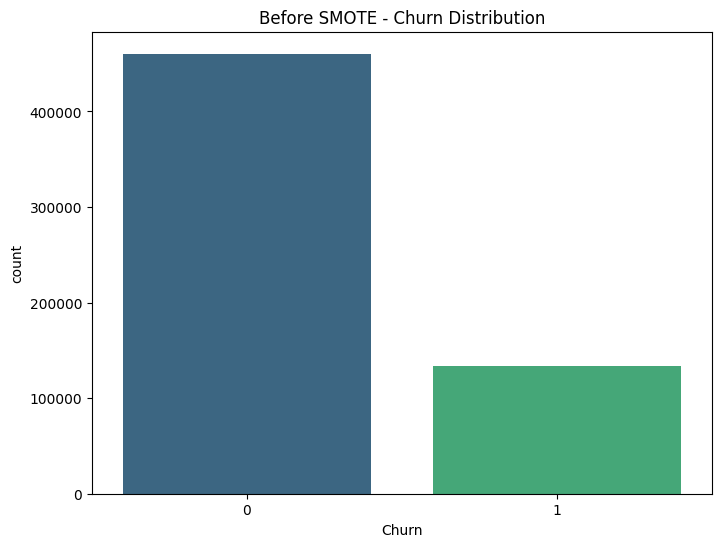

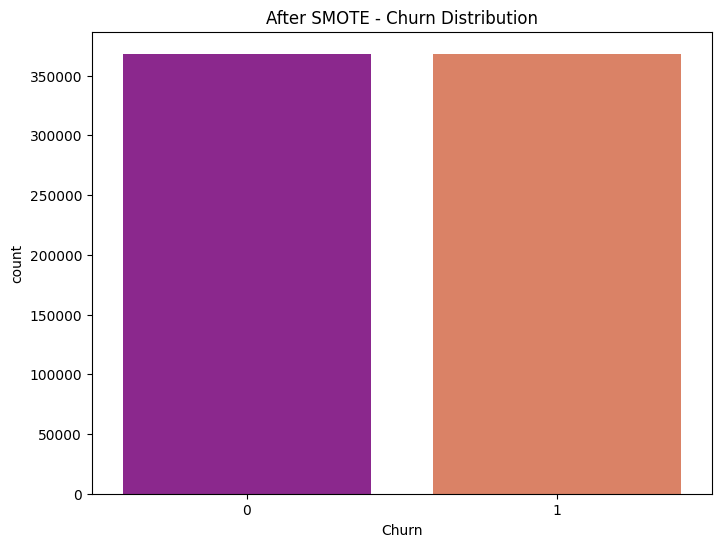

In [ ]:
# Before SMOTE
plt.figure(figsize=(8,6)) # size of the countplot
sns.countplot(x=y,palette='viridis') # Plot class distribution of target variable
plt.title("Before SMOTE - Churn Distribution") # Title name of the plot
plt.show() #Display the plot

# After SMOTE
plt.figure(figsize=(8,6)) #size of the counplot
sns.countplot(x=y_train_res,palette='plasma')  # y_train_res is the balanced target after SMOTE
plt.title("After SMOTE - Churn Distribution") #Title of the count plot
plt.show() #Display the plot

In [ ]:
num_cols=['tenure', 'MonthlyCharges', 'TotalCharges'] # Numerical columns for scaling
scaler=StandardScaler() # Initialize StandardScaler
x_train_res[num_cols]=scaler.fit_transform(x_train_res[num_cols]) # Fit on training resempled
x_val[num_cols]=scaler.transform(x_val[num_cols]) # Transform validation
test_df[num_cols]=scaler.transform(test_df[num_cols]) # Transform validation

In [ ]:
x_train=x_train_res # Assign resampled features (after SMOTE) to training features
y_train=y_train_res # Assign resampled target labels (after SMOTE) to training features

In [ ]:
# Make a copy of test dataset
test_features = test_df.copy()

# Drop Churn if it exists
if 'Churn' in test_features.columns:
    test_features = test_features.drop(['Churn'], axis=1)
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

In [ ]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced') #Initialize Logistic Regression
lr_model.fit(x_train, y_train) #Train Logistic Regression
y_prob_val = lr_model.predict_proba(x_val)[:,1]  # Probability of churn (class 1)
y_pred_val = (y_prob_val > 0.5).astype(int) # Convert probabilities to binary predictions
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_val))
print("\nClassification Report:\n", classification_report(y_val, y_pred_val))


Validation Accuracy: 0.8208668871330119

Confusion Matrix:
 [[75832 16244]
 [ 5044 21719]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88     92076
           1       0.57      0.81      0.67     26763

    accuracy                           0.82    118839
   macro avg       0.75      0.82      0.77    118839
weighted avg       0.86      0.82      0.83    118839



In [ ]:
# Predict probabilities
y_prob = lr_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (churn)
threshold = 0.45
y_pred_tuned = (y_prob > threshold).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_val, y_pred_tuned))

Confusion Matrix:
 [[74207 17869]
 [ 4398 22365]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87     92076
           1       0.56      0.84      0.67     26763

    accuracy                           0.81    118839
   macro avg       0.75      0.82      0.77    118839
weighted avg       0.86      0.81      0.82    118839



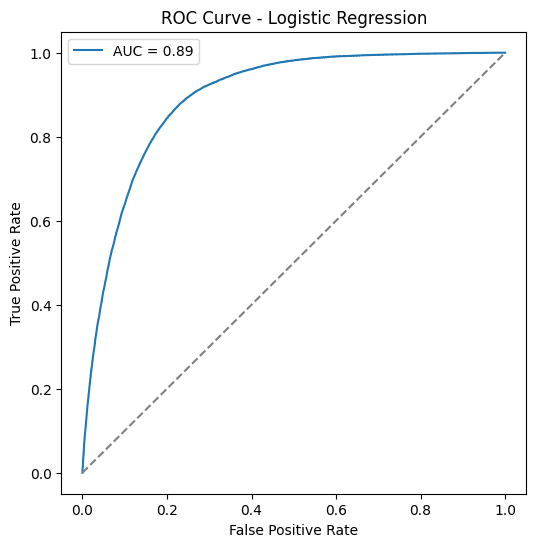

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_prob_val)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [ ]:
# Predict probabilities for test dataset
y_prob_test = lr_model.predict_proba(test_df.drop(['Churn'], axis=1))[:, 1]  # Probability of churn (class 1)

# Apply tuned threshold
y_pred_test = (y_prob_test > threshold).astype(int)

In [ ]:
submission=pd.read_csv('/content/sample_submission.csv') #Load the sample submission file provided by Kaggle competition.
submission['Churn']=y_pred_test ## Replace the 'Churn' column with your model's predictions (y_pred_test).
submission.to_csv("submission.csv", index=False) ## Save the final submission file in CSV format.